### LBP+SVM

In [17]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from skimage.feature import local_binary_pattern

# 1. Parameters
LBP_P, LBP_R = 8, 1
DATA_PATH = '../Aerial_Landscapes'
CATEGORIES = sorted(os.listdir(DATA_PATH))

# 2. LBP feature extractor
def extract_lbp_features(img, P=LBP_P, R=LBP_R):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, P + 3),
                           range=(0, P + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

# 3. Load images and features
X, y, paths = [], [], []
print("Loading images and extracting features …")
for label, category in enumerate(CATEGORIES):
    folder = os.path.join(DATA_PATH, category)
    for file in tqdm(os.listdir(folder)[:800]):         # remove [:800] to use all images
        fpath = os.path.join(folder, file)
        img = cv2.imread(fpath)
        if img is None:
            continue
        X.append(extract_lbp_features(img))
        y.append(label)
        paths.append(fpath)

X, y = np.array(X), np.array(y)

# 4. Train‑test split (including paths)
X_tr, X_te, y_tr, y_te, train_paths, test_paths = train_test_split(
    X, y, paths,
    test_size=0.20,
    stratify=y,
    random_state=42
)


Loading images and extracting features …


100%|██████████| 800/800 [00:02<00:00, 297.28it/s]


Training SVM …

Evaluation Results:

              precision    recall  f1-score   support

 Agriculture       0.49      0.59      0.54       160
     Airport       0.41      0.44      0.43       160
       Beach       0.56      0.43      0.49       160
        City       0.40      0.41      0.40       160
      Desert       0.59      0.57      0.58       160
      Forest       0.81      0.86      0.83       160
   Grassland       0.75      0.72      0.73       160
     Highway       0.56      0.46      0.51       160
        Lake       0.67      0.56      0.61       160
    Mountain       0.53      0.78      0.63       160
     Parking       0.58      0.56      0.57       160
        Port       0.77      0.70      0.73       160
     Railway       0.55      0.47      0.51       160
 Residential       0.53      0.66      0.59       160
       River       0.42      0.34      0.38       160

    accuracy                           0.57      2400
   macro avg       0.57      0.57      0.57

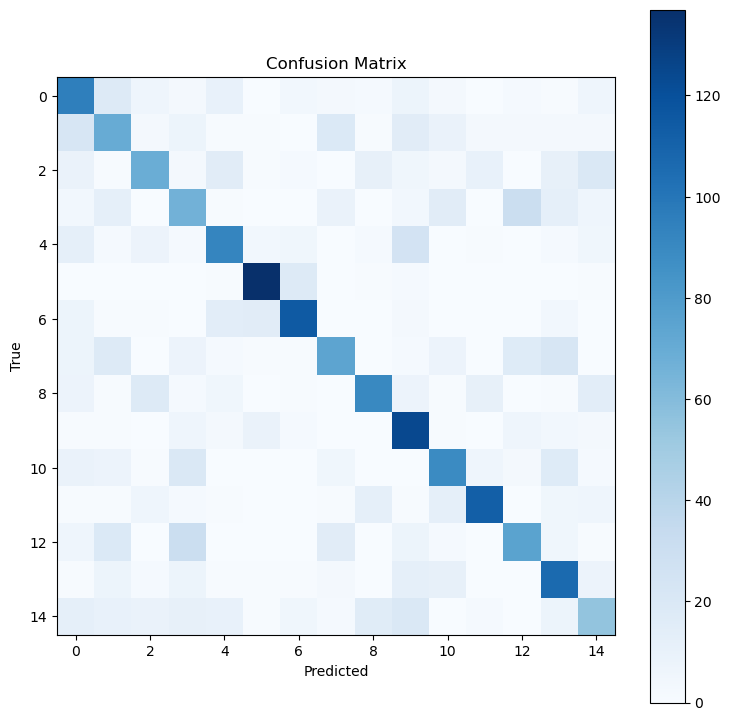

In [8]:

# 5. Train SVM
print("Training SVM …")
model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_tr, y_tr)

# 6. Predict and evaluate
y_pred = model.predict(X_te)
print("\nEvaluation Results:\n")
print(classification_report(y_te, y_pred, target_names=CATEGORIES))

conf_mat = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(9, 9))
plt.imshow(conf_mat, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


In [9]:

# 7. Save classified images
correct_dir   = 'LBP_SVM/correct_samples'
incorrect_dir = 'LBP_SVM/incorrect_samples'
os.makedirs(correct_dir,   exist_ok=True)
os.makedirs(incorrect_dir, exist_ok=True)

max_to_save = 5            # set to None to save all samples
correct_saved = incorrect_saved = 0

for i, (true_lab, pred_lab, img_path) in enumerate(zip(y_te, y_pred, test_paths)):
    img = cv2.imread(img_path)
    if img is None:
        continue
    if true_lab == pred_lab:
        if max_to_save is None or correct_saved < max_to_save:
            fname = f"true_{CATEGORIES[true_lab]}_pred_{CATEGORIES[pred_lab]}_{i}.jpg"
            cv2.imwrite(os.path.join(correct_dir, fname), img)
            correct_saved += 1
    else:
        if max_to_save is None or incorrect_saved < max_to_save:
            fname = f"true_{CATEGORIES[true_lab]}_pred_{CATEGORIES[pred_lab]}_{i}.jpg"
            cv2.imwrite(os.path.join(incorrect_dir, fname), img)
            incorrect_saved += 1
    if (max_to_save is not None and
        correct_saved >= max_to_save and
        incorrect_saved >= max_to_save):
        break

print(f"Saved {correct_saved} correct and {incorrect_saved} incorrect samples "
      f"to {correct_dir} / {incorrect_dir}.")


Saved 5 correct and 5 incorrect samples to LBP_SVM/correct_samples / LBP_SVM/incorrect_samples.


### LBP+KNN

Training KNN...
Evaluation Results:

              precision    recall  f1-score   support

 Agriculture       0.47      0.60      0.52       160
     Airport       0.27      0.32      0.29       160
       Beach       0.37      0.39      0.38       160
        City       0.41      0.45      0.43       160
      Desert       0.52      0.50      0.51       160
      Forest       0.78      0.84      0.81       160
   Grassland       0.74      0.62      0.68       160
     Highway       0.42      0.39      0.40       160
        Lake       0.51      0.47      0.49       160
    Mountain       0.52      0.65      0.58       160
     Parking       0.58      0.50      0.54       160
        Port       0.61      0.59      0.60       160
     Railway       0.52      0.34      0.41       160
 Residential       0.51      0.60      0.55       160
       River       0.39      0.28      0.33       160

    accuracy                           0.50      2400
   macro avg       0.51      0.50      0.50

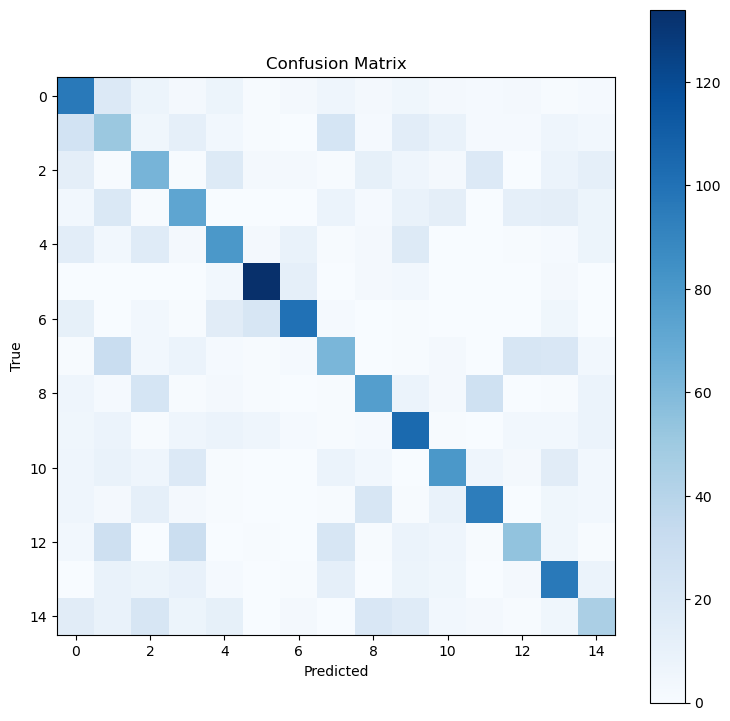

In [10]:
from sklearn.neighbors import KNeighborsClassifier
# Train KNN model
print("Training KNN...")
model2 = KNeighborsClassifier(n_neighbors=5)  # Adjust the number of neighbors as needed
model2.fit(X_train, y_train)

# Test and evaluate
y_pred = model2.predict(X_test)
print("Evaluation Results:\n")
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

# Visualize confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 9))
plt.imshow(conf_mat, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

In [11]:

# 7. Save classified images
correct_dir   = 'LBP_KNN/correct_samples'
incorrect_dir = 'LBP_KNN/incorrect_samples'
os.makedirs(correct_dir,   exist_ok=True)
os.makedirs(incorrect_dir, exist_ok=True)

max_to_save = 5            # set to None to save all samples
correct_saved = incorrect_saved = 0

for i, (true_lab, pred_lab, img_path) in enumerate(zip(y_te, y_pred, test_paths)):
    img = cv2.imread(img_path)
    if img is None:
        continue
    if true_lab == pred_lab:
        if max_to_save is None or correct_saved < max_to_save:
            fname = f"true_{CATEGORIES[true_lab]}_pred_{CATEGORIES[pred_lab]}_{i}.jpg"
            cv2.imwrite(os.path.join(correct_dir, fname), img)
            correct_saved += 1
    else:
        if max_to_save is None or incorrect_saved < max_to_save:
            fname = f"true_{CATEGORIES[true_lab]}_pred_{CATEGORIES[pred_lab]}_{i}.jpg"
            cv2.imwrite(os.path.join(incorrect_dir, fname), img)
            incorrect_saved += 1
    if (max_to_save is not None and
        correct_saved >= max_to_save and
        incorrect_saved >= max_to_save):
        break

print(f"Saved {correct_saved} correct and {incorrect_saved} incorrect samples "
      f"to {correct_dir} / {incorrect_dir}.")


Saved 5 correct and 5 incorrect samples to LBP_KNN/correct_samples / LBP_KNN/incorrect_samples.


### SIFT+SVM

In [12]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Dataset path and categories
DATA_PATH = '../Aerial_Landscapes'  # Replace with your local path or the extracted path
CATEGORIES = sorted(os.listdir(DATA_PATH))  # Automatically detect categories

# Build lists of image paths and labels
image_paths = []
labels = []
for label, category in enumerate(CATEGORIES):
    category_path = os.path.join(DATA_PATH, category)
    for file in os.listdir(category_path)[:800]:  # Adjust the number of images per category as needed
        img_path = os.path.join(category_path, file)
        image_paths.append(img_path)
        labels.append(label)

labels = np.array(labels)

# Split into training and testing sets
train_paths, test_paths, y_train, y_test = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42)

# Initialize SIFT extractor
sift = cv2.SIFT_create()

# —— 1. Extract SIFT descriptors from training images and collect all descriptors for building the visual vocabulary —— 
train_descriptors_list = []          # Store descriptors for each training image (may be None)
all_train_descriptors = []           # All descriptors for k-means

print("Extracting SIFT descriptors from training images...")
for path in tqdm(train_paths, desc="Training SIFT extraction"):
    image = cv2.imread(path)
    if image is None:
        train_descriptors_list.append(None)
        continue
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    train_descriptors_list.append(descriptors)
    if descriptors is not None:
        all_train_descriptors.append(descriptors)

# Combine all descriptors from training images (note that some images may not have detected keypoints)
if len(all_train_descriptors) > 0:
    all_train_descriptors = np.vstack(all_train_descriptors)
else:
    raise ValueError("No SIFT descriptors were extracted from the training images. Please check the data or SIFT parameters.")

# —— 2. Use k-means to build the visual vocabulary —— 
k = 50  # Number of words in the visual vocabulary, can be adjusted as needed
print("Clustering descriptors with k-means (k=%d)..." % k)
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(all_train_descriptors)

# Define a function to compute the BoVW histogram given a set of descriptors
def compute_bovw_histogram(descriptors, kmeans, k):
    # If no descriptors, return a histogram of all zeros
    if descriptors is None:
        return np.zeros(k)
    words = kmeans.predict(descriptors)
    hist, _ = np.histogram(words, bins=np.arange(0, k + 1))
    hist = hist.astype("float")
    if hist.sum() != 0:
        hist /= hist.sum()
    return hist

# —— 3. Compute BoVW histograms for the training set —— 
X_train = []
for descriptors in train_descriptors_list:
    hist = compute_bovw_histogram(descriptors, kmeans, k)
    X_train.append(hist)
X_train = np.array(X_train)

# —— 4. Extract SIFT descriptors from test images and compute BoVW histograms —— 
X_test = []
print("Extracting SIFT descriptors from test images and computing histograms...")
for path in tqdm(test_paths, desc="Test SIFT extraction"):
    image = cv2.imread(path)
    if image is None:
        X_test.append(np.zeros(k))
        continue
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    hist = compute_bovw_histogram(descriptors, kmeans, k)
    X_test.append(hist)
X_test = np.array(X_test)

Extracting SIFT descriptors from training images...


Training SIFT extraction: 100%|██████████| 9600/9600 [01:06<00:00, 144.99it/s]


Clustering descriptors with k-means (k=50)...
Extracting SIFT descriptors from test images and computing histograms...


Test SIFT extraction: 100%|██████████| 2400/2400 [00:21<00:00, 110.09it/s]


Training SVM...
Evaluation Results:

              precision    recall  f1-score   support

 Agriculture       0.61      0.67      0.64       160
     Airport       0.55      0.61      0.58       160
       Beach       0.55      0.51      0.53       160
        City       0.60      0.69      0.64       160
      Desert       0.53      0.59      0.56       160
      Forest       0.88      0.86      0.87       160
   Grassland       0.55      0.54      0.55       160
     Highway       0.60      0.54      0.57       160
        Lake       0.43      0.34      0.38       160
    Mountain       0.75      0.79      0.77       160
     Parking       0.89      0.86      0.88       160
        Port       0.68      0.56      0.61       160
     Railway       0.60      0.69      0.64       160
 Residential       0.75      0.82      0.79       160
       River       0.45      0.39      0.42       160

    accuracy                           0.63      2400
   macro avg       0.63      0.63      0.63

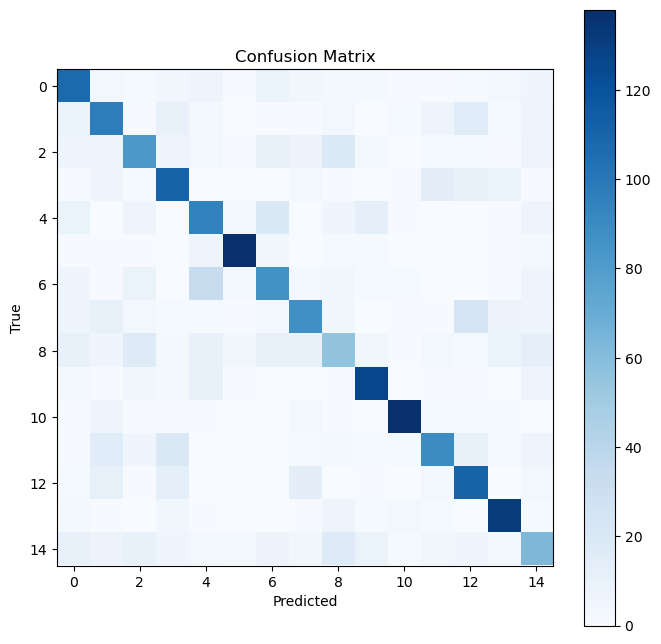

In [13]:
# —— 5. Train the SVM classifier —— 
print("Training SVM...")
model3 = SVC(kernel='rbf', C=10, gamma='scale')
model3.fit(X_train, y_train)

# —— 6. Test and evaluate —— 
y_pred = model3.predict(X_test)
print("Evaluation Results:\n")
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

# Visualize confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
plt.imshow(conf_mat, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

In [14]:

# 7. Save classified images
correct_dir   = 'SIFT_SVM/correct_samples'
incorrect_dir = 'SIFT_SVM/incorrect_samples'
os.makedirs(correct_dir,   exist_ok=True)
os.makedirs(incorrect_dir, exist_ok=True)

max_to_save = 5            # set to None to save all samples
correct_saved = incorrect_saved = 0

for i, (true_lab, pred_lab, img_path) in enumerate(zip(y_te, y_pred, test_paths)):
    img = cv2.imread(img_path)
    if img is None:
        continue
    if true_lab == pred_lab:
        if max_to_save is None or correct_saved < max_to_save:
            fname = f"true_{CATEGORIES[true_lab]}_pred_{CATEGORIES[pred_lab]}_{i}.jpg"
            cv2.imwrite(os.path.join(correct_dir, fname), img)
            correct_saved += 1
    else:
        if max_to_save is None or incorrect_saved < max_to_save:
            fname = f"true_{CATEGORIES[true_lab]}_pred_{CATEGORIES[pred_lab]}_{i}.jpg"
            cv2.imwrite(os.path.join(incorrect_dir, fname), img)
            incorrect_saved += 1
    if (max_to_save is not None and
        correct_saved >= max_to_save and
        incorrect_saved >= max_to_save):
        break

print(f"Saved {correct_saved} correct and {incorrect_saved} incorrect samples "
      f"to {correct_dir} / {incorrect_dir}.")


Saved 5 correct and 5 incorrect samples to SIFT_SVM/correct_samples / SIFT_SVM/incorrect_samples.


### SIFT+KNN

Training KNN...
Evaluation Results:

              precision    recall  f1-score   support

 Agriculture       0.48      0.57      0.53       160
     Airport       0.32      0.55      0.40       160
       Beach       0.41      0.23      0.29       160
        City       0.43      0.82      0.57       160
      Desert       0.50      0.41      0.45       160
      Forest       0.80      0.88      0.84       160
   Grassland       0.59      0.33      0.42       160
     Highway       0.44      0.47      0.45       160
        Lake       0.30      0.21      0.25       160
    Mountain       0.64      0.68      0.65       160
     Parking       0.91      0.73      0.81       160
        Port       0.68      0.34      0.45       160
     Railway       0.51      0.62      0.56       160
 Residential       0.62      0.73      0.67       160
       River       0.36      0.23      0.28       160

    accuracy                           0.52      2400
   macro avg       0.53      0.52      0.51

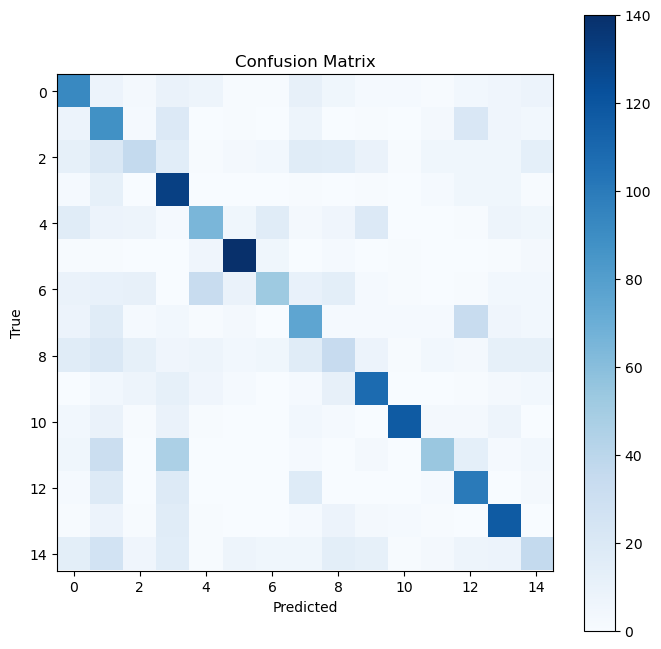

In [15]:
# Train KNN model
print("Training KNN...")
model4 = KNeighborsClassifier(n_neighbors=5)  # Adjust the number of neighbors as needed
model4.fit(X_train, y_train)

# Test and evaluate
y_pred = model4.predict(X_test)
print("Evaluation Results:\n")
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

# Visualize confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
plt.imshow(conf_mat, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

In [16]:

# 7. Save classified images
correct_dir   = 'SIFT_KNN/correct_samples'
incorrect_dir = 'SIFT_KNN/incorrect_samples'
os.makedirs(correct_dir,   exist_ok=True)
os.makedirs(incorrect_dir, exist_ok=True)

max_to_save = 5            # set to None to save all samples
correct_saved = incorrect_saved = 0

for i, (true_lab, pred_lab, img_path) in enumerate(zip(y_te, y_pred, test_paths)):
    img = cv2.imread(img_path)
    if img is None:
        continue
    if true_lab == pred_lab:
        if max_to_save is None or correct_saved < max_to_save:
            fname = f"true_{CATEGORIES[true_lab]}_pred_{CATEGORIES[pred_lab]}_{i}.jpg"
            cv2.imwrite(os.path.join(correct_dir, fname), img)
            correct_saved += 1
    else:
        if max_to_save is None or incorrect_saved < max_to_save:
            fname = f"true_{CATEGORIES[true_lab]}_pred_{CATEGORIES[pred_lab]}_{i}.jpg"
            cv2.imwrite(os.path.join(incorrect_dir, fname), img)
            incorrect_saved += 1
    if (max_to_save is not None and
        correct_saved >= max_to_save and
        incorrect_saved >= max_to_save):
        break

print(f"Saved {correct_saved} correct and {incorrect_saved} incorrect samples "
      f"to {correct_dir} / {incorrect_dir}.")


Saved 5 correct and 5 incorrect samples to SIFT_KNN/correct_samples / SIFT_KNN/incorrect_samples.
